# Tarefa

Com base na tarefa realizada no módulo anterior, vamos fazer um diagnóstico do modelo.

Carregue a base ```previsao_de_renda2.csv```. Separe em uma base de treino e uma base de teste.

Vamos resgatar a melhor versão do modelo de previsão de renda que você fez para esta base. 

- Substitua missings pela média
- Rode novamente o modelo na base de treino (ou desenvolva-o caso não tenha o registro guardado). 

Este modelo deve prever a variável ```renda``` com base nas demais variáveis exceto ```data_ref``` e ```index```. Já vimos que a variável renda é melhor modelada com a transformação ```log()```, não se esqueça disso.

In [180]:
# Importa a biblioteca pandas para manipulação de dados em DataFrames
import pandas as pd

# Importa a biblioteca matplotlib (mas o nome 'plt' está incorreto aqui, o correto seria 'import matplotlib.pyplot as plt')
import matplotlib as plt

# Importa a biblioteca numpy para operações numéricas
import numpy as np

# Importa a função para modelos lineares do statsmodels usando fórmulas
import statsmodels.formula.api as smf

# Importa seaborn para visualização de dados estatísticos
import seaborn as sns

# Importa o módulo pyplot do matplotlib para criação de gráficos
import matplotlib.pyplot as plt

# Importa a API principal do statsmodels para análise estatística
import statsmodels.api as sm

# Importa novamente statsmodels.formula.api como smf (já foi importado acima, esta linha é redundante)
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split

from statsmodels.stats.outliers_influence import variance_inflation_factor as vif


## Construindo a regressão

In [181]:
def esp_vs_obs(data, res, X, y_pred, y_true, transformar=False, amostragem=False, tamanho=1000):
    pred_ols = res.get_prediction()
    pred_summary = pred_ols.summary_frame()

    iv_l = pred_summary['obs_ci_lower']
    iv_u = pred_summary['obs_ci_upper']
    m_l = pred_summary['mean_ci_lower']
    m_u = pred_summary['mean_ci_upper']

    if amostragem:
        data = data.head(tamanho)
        y_pred = y_pred.head(tamanho)
        iv_l = iv_l.head(tamanho)
        iv_u = iv_u.head(tamanho)
        m_l = m_l.head(tamanho)
        m_u = m_u.head(tamanho)

    # Cria uma cópia do dataframe ordenado pelo eixo X
    df_plot = data.copy()
    df_plot["y_pred"] = y_pred
    df_plot["iv_l"] = iv_l
    df_plot["iv_u"] = iv_u
    df_plot["m_l"] = m_l
    df_plot["m_u"] = m_u
    df_plot["y_real"] = np.log(data[y_true]) if transformar else data[y_true]
    df_plot = df_plot.sort_values(by=X)

    fig, ax = plt.subplots(figsize=(8, 6))

    # Scatter dos pontos observados
    ax.plot(df_plot[X], df_plot["y_pred"], 'o', label="Dados observados", alpha=0.5)

    # Linhas conectando em ordem
    ax.plot(df_plot[X], df_plot["y_real"], 'b-', label='Média da simulação (log)' if transformar else 'Média da simulação')
    ax.plot(df_plot[X], df_plot["y_pred"], 'r--', label='Estimativa OLS')
    ax.plot(df_plot[X], df_plot["iv_u"], 'r--', label='Banda de confiança para y')
    ax.plot(df_plot[X], df_plot["iv_l"], 'r--')
    ax.plot(df_plot[X], df_plot["m_u"], 'g:', label='Banda de confiança para média')
    ax.plot(df_plot[X], df_plot["m_l"], 'g:')

    ax.set_xlabel(X)
    ax.set_ylabel(y_true)
    ax.set_title("Expectativa vs Observado")
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

In [182]:
previsao_renda = pd.read_csv('./Dataset/previsao_de_renda_II.csv')
previsao_renda.loc[previsao_renda['tempo_emprego'].isna(), 'tempo_emprego'] = previsao_renda.tempo_emprego.mean()
previsao_renda.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda
0,2015-01-01,5762,M,S,N,0,Empresário,Superior completo,Casado,Casa,47,16.717808,2.0,11138.14
1,2015-01-01,1279,M,S,N,0,Assalariado,Superior incompleto,Casado,Casa,30,9.600000,2.0,2424.81
2,2015-01-01,14111,M,S,N,0,Assalariado,Superior completo,Casado,Casa,28,8.208219,2.0,13749.66
3,2015-01-01,8189,M,N,S,2,Assalariado,Médio,Casado,Casa,44,1.301370,4.0,2361.84
4,2015-01-01,1830,F,N,S,2,Assalariado,Superior completo,Casado,Casa,33,1.254795,4.0,790.78


In [183]:
# Define a variável dependente (target) como a nova coluna 'log_renda'
y = previsao_renda['renda']

# Define as variáveis independentes removendo as colunas 'renda' e 'log_renda'
X = previsao_renda.drop(columns=['renda'])

# Separa os dados em treino e teste (60% treino, 40% teste, com semente fixa para reprodutibilidade)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=100)

# Junta as variáveis independentes e dependente para formar o dataframe de treino
df_treino = X_train.join(y_train)

# Junta as variáveis independentes e dependente para formar o dataframe de teste
df_teste = X_test.join(y_test)

# Seleciona uma amostra de 30.000 linhas do conjunto de treino para análise de resíduos
df_resid_check = df_treino.sample(30000, random_state=100).reset_index(drop=True)

In [184]:
df_resid_check

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda
0,2015-02-01,5770,F,S,N,0,Pensionista,Médio,Solteiro,Casa,63,7.746165,1.0,2199.86
1,2015-09-01,1403,F,N,S,0,Pensionista,Médio,Casado,Casa,58,7.746165,2.0,23220.92
2,2015-12-01,16212,F,N,S,0,Servidor público,Superior completo,Casado,Casa,34,9.465753,2.0,9440.31
3,2016-01-01,2703,F,N,S,0,Assalariado,Médio,Casado,Casa,48,10.731507,2.0,2278.68
4,2015-11-01,6122,M,S,S,0,Assalariado,Superior completo,Casado,Casa,29,1.495890,2.0,754.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,2015-07-01,12756,M,N,S,1,Servidor público,Superior completo,Casado,Casa,29,6.452055,3.0,31248.16
29996,2015-07-01,14969,F,N,S,0,Pensionista,Médio,Casado,Casa,58,7.746165,2.0,23529.12
29997,2015-04-01,6532,M,S,S,0,Assalariado,Superior completo,Casado,Casa,45,18.926027,2.0,27901.51
29998,2015-08-01,4995,M,S,S,1,Assalariado,Superior completo,Casado,Casa,32,10.638356,3.0,92383.54


In [185]:
previsao_renda.idade.values.max()

68

In [186]:
# Definir pontos de corte para testar
C1_values = np.linspace(start=previsao_renda['tempo_emprego'].min(),
                       stop=previsao_renda['tempo_emprego'].max(),
                       num=5)  # Reduzindo para 5 pontos para cada variável

C2_values = np.linspace(start=previsao_renda['qtd_filhos'].min(),
                       stop=previsao_renda['qtd_filhos'].max(),
                       num=5)

C3_values = np.linspace(start=previsao_renda['idade'].min(),
                       stop=previsao_renda['idade'].max(),
                       num=5)

# Lista para armazenar resultados
resultados = []

# Testar combinações de pontos de corte
for c1 in C1_values:
    # Criar segmentos para tempo_emprego
    df_resid_check['X1_1'] = np.where(df_resid_check['tempo_emprego'] <= c1, 
                                     df_resid_check['tempo_emprego'], c1)
    df_resid_check['X1_2'] = np.where(df_resid_check['tempo_emprego'] > c1, 
                                     df_resid_check['tempo_emprego'] - c1, 0)
    
    for c2 in C2_values:
        # Criar segmentos para qtd_filhos
        df_resid_check['X2_1'] = np.where(df_resid_check['qtd_filhos'] <= c2, 
                                         df_resid_check['qtd_filhos'], c2)
        df_resid_check['X2_2'] = np.where(df_resid_check['qtd_filhos'] > c2, 
                                         df_resid_check['qtd_filhos'] - c2, 0)
        
        for c3 in C3_values:
            # Criar segmentos para idade
            df_resid_check['X3_1'] = np.where(df_resid_check['idade'] <= c3, 
                                            df_resid_check['idade'], c3)
            df_resid_check['X3_2'] = np.where(df_resid_check['idade'] > c3, 
                                            df_resid_check['idade'] - c3, 0)
            
            # Ajustar modelo
            formula = 'I(np.log(renda+1)) ~ I(np.log(X1_1 + 10)) + I(np.log(X1_2 + 10)) + X2_1 + X2_2 + I(np.log(X3_1 + 10)) + I(np.log(X3_2 + 10))'
            try:
                modelo = smf.ols(formula, data=df_resid_check).fit()
                
                # Armazenar resultados
                resultados.append({
                    'corte_tempo_emprego': c1,
                    'corte_qtd_filhos': c2,
                    'corte_idade': c3,
                    'R2': modelo.rsquared,
                    'AIC': modelo.aic,
                    'BIC': modelo.bic
                })
            except:
                continue

# Converter para DataFrame
df_resultados = pd.DataFrame(resultados)

# Mostrar melhores combinações
df_resultados.sort_values('R2', ascending=False).head(10)

,corte_tempo_emprego,corte_qtd_filhos,corte_idade,R2,AIC,BIC
32,10.815068,3.5,45.0,0.376620,85807.745564,85865.908233
42,10.815068,10.5,45.0,0.376601,85808.615997,85866.778666
37,10.815068,7.0,45.0,0.376601,85808.615997,85866.778666
27,10.815068,0.0,45.0,0.376601,85806.639124,85856.492840
47,10.815068,14.0,45.0,0.376601,85806.639124,85856.492840
33,10.815068,3.5,56.5,0.375967,85839.128269,85897.290938
43,10.815068,10.5,56.5,0.375959,85839.506706,85897.669374
38,10.815068,7.0,56.5,0.375959,85839.506706,85897.669374
28,10.815068,0.0,56.5,0.375959,85837.522634,85887.376350
48,10.815068,14.0,56.5,0.375959,85837.522634,85887.376350


In [187]:
C1 = 10.815068
C2 =  3.5
C3 = 45


### CRIANDO DOIS SEGMENTOS PARA A VARIÁVEL TEMPO_EMPREGO
# Cria a variável segmentada X1_1: igual a X1 se X1 <= C1, senão igual a C1
df_resid_check['X1_1'] = (df_resid_check['tempo_emprego'] <= C1) * df_resid_check['tempo_emprego'] + (df_resid_check['tempo_emprego'] > C1) * C1

# Cria a variável segmentada X1_2: igual a X1 - C1 se X1 > C1, senão zero
df_resid_check['X1_2'] = (df_resid_check['tempo_emprego'] > C1) * (df_resid_check['tempo_emprego'] - C1)


### CRIANDO DOIS SEGMENTOS PARA QTD_FILHOS
# Cria a variável segmentada X2_1: igual a qtd_filhos se qtd_filhos <= C2, senão igual a C2
df_resid_check['X2_1'] = (df_resid_check['qtd_filhos'] <= C2) * df_resid_check['qtd_filhos'] + (df_resid_check['qtd_filhos'] > C2) * C2

# Cria a variável segmentada X1_2: igual a qtd_filhos - C2 se X1 > C2, senão zero
df_resid_check['X2_2'] = (df_resid_check['qtd_filhos'] > C2) * (df_resid_check['qtd_filhos'] - C2)


### CRIANDO DOIS SEGMENTOS PARA A VARIÁVEL IDADE
# Cria a variável segmentada X3_1: igual a idade se idade <= C3, senão igual a C3
df_resid_check['X3_1'] = (df_resid_check['idade'] <= C3) * df_resid_check['idade'] + (df_resid_check['idade'] > C3) * C3

# Cria a variável segmentada X1_2: igual a X1 - C3 se X1 > C3, senão zero
df_resid_check['X3_2'] = (df_resid_check['idade'] > C3) * (df_resid_check['idade'] - C3)

In [188]:
# Ajusta o modelo de regressão linear segmentado usando as transformações logarítmicas das variáveis segmentadas
res_segmentada = smf.ols('I(np.log(renda+1)) ~ I(np.log(X1_1 + 10)) + I(np.log(X1_2 + 10)) + X2_1 + X2_2 + I(np.log(X3_1 + 10))  + I(np.log(X3_2 + 10))', data=df_resid_check).fit() 

R-quadrado: 37.66%


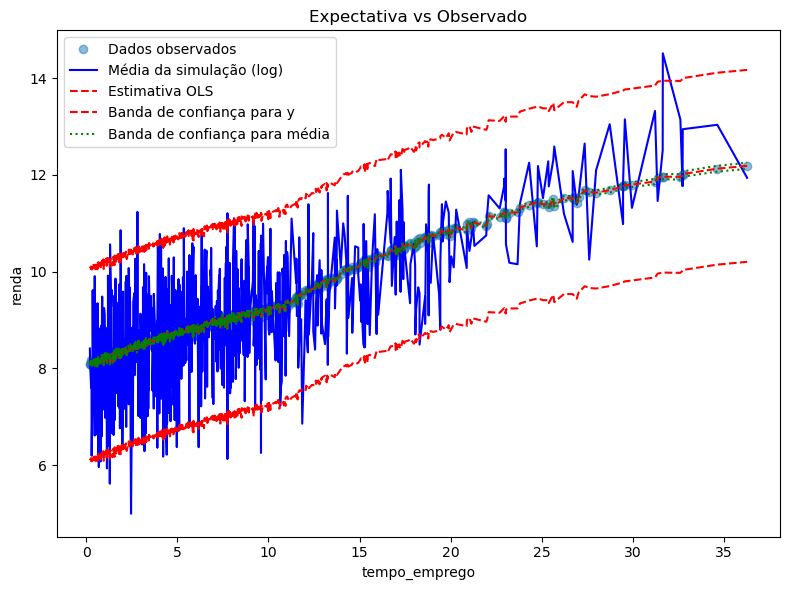

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     I(np.log(renda + 1))   R-squared:                       0.377
Model:                              OLS   Adj. R-squared:                  0.376
Method:                   Least Squares   F-statistic:                     3020.
Date:                  Thu, 10 Jul 2025   Prob (F-statistic):               0.00
Time:                          01:42:25   Log-Likelihood:                -42897.
No. Observations:                 30000   AIC:                         8.581e+04
Df Residuals:                     29993   BIC:                         8.587e+04
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -1.8260      0.184     -9.945      0.000      -2.186      -1.466
I(np.log(X1_1 + 10))     1.6916      0.032     53.219      0.000       1.629       1.754
I(np.log(X1_2 + 10))     2.3752      0.029     83.036      0.000       2.319       2.431
X2_1                    -0.0071      0.009     -0.801      0.423      -0.025       0.010
X2_2                     0.0376      0.046      0.823      0.410      -0.052       0.127
I(np.log(X3_1 + 10))     0.2727      0.054      5.079      0.000       0.167       0.378
I(np.log(X3_2 + 10))    -0.2205      0.021    -10.679      0.000      -0.261      -0.180
==============================================================================
Omnibus:                      146.098   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              107.552
Skew:                          -0.028   Prob(JB):                     4.42e-24
Kurtosis:                       2.712   Cond. No.                         197.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [189]:
y_pred = res_segmentada.predict(df_resid_check[['X1_1', 'X1_2', 'X2_1', 'X2_2', 'X3_1', 'X3_2']])

print(f'R-quadrado: {res_segmentada.rsquared:.2%}')
esp_vs_obs(data=df_resid_check, res=res_segmentada, X='tempo_emprego', y_true='renda', y_pred = y_pred, transformar=True, amostragem=True);
res_segmentada.summary()

## Verifique as suposições do modelo

Faça uma análise para avaliar as suposições básicas:

- Os resíduos desse modelo possuem distribuição Normal (ou algo próximo)?
- Verifique a independência dos resíduos
    - Faça um gráfico dos resíduos versus os valores preditos
    - Avalie se há padrões dos resíduos versus cada uma das variáveis do modelo
    - Avalie se o valor médio dos resíduos aparenta ter relação com o mês de referência
- Avalie se a variância da variável resposta parece ser conforme os valores previstos.

Você considera que as suposições estão atendidas? Há algum impacto em eventuais desvios?

<Axes: ylabel='renda'>

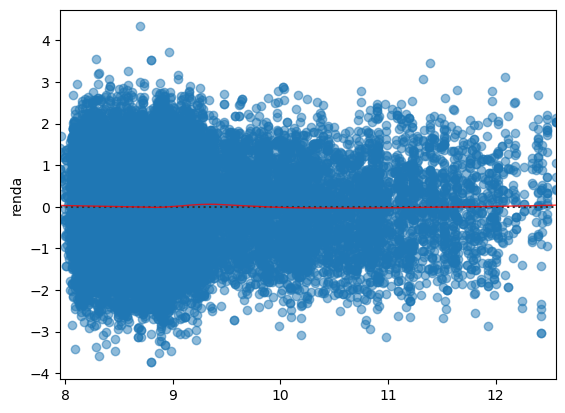

In [190]:
sns.residplot(
    x=y_pred,
    y=np.log(df_resid_check['renda'] + 1),
    data=df_resid_check,
    lowess=True,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red", "lw": 1, "alpha": 0.8},
)

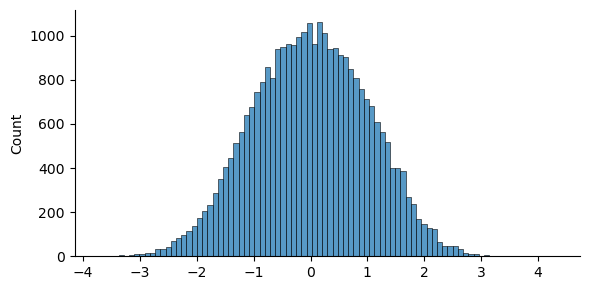

In [191]:
sns.displot(res_segmentada.resid, height=3, aspect=2);